# Using Deep Learning to detect COVID-19 presence from x-ray scans

Disclaimer: I am not a doctor nor a medical researcher. This work is only intended as a source of inspiration for further studies.

## COVID-19-xray


The more the pandemic crisis progresses, the more it gets important that countries perform tests to help understand and stop the spread of COVID-19.
Unfortunately, the capacity for COVID-19 testing is still low in many countries. 

### How are tests performed?

The standard COVID-19 tests are called PCR (Polymerase chain reaction) tests. This family of tests looks for the existence of antibodies of a given infection. Two main issues with this test are:

1. a shortage a tests available worldwide
2. a patient might be carring the virus without having symptoms. In this case the test fails to identify infected patients

[Dr. Joseph Paul Cohen, Postdoctoral Fellow at University of Montreal](https://josephpcohen.com/w/), recently open sourced a [database](https://github.com/ieee8023/covid-chestxray-dataset) containing chest x-ray pictures of patients suffering from the COVID-19 disease. 


The database only contains pictures of patients suffering from COVID-19. In order to build a classifier for xray images we first need to find similar x-ray images of people who are not suffering from the disease.
It turns out Kaggle has a database with chest x-ray images of patients suffering of pneumonia and healthy patients. Hence, we are going to use both sources images in our dataset.


The notebook is organized as follows:

1. Data Preparation  

2. Train Network using Fastai

3. Optimize Network

4. Test

5. What's Next

But first let's import necessary libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os



# 1. Data Preparation

Let's import Fastai, create useful paths and create covid_df

In [2]:
from fastai import *
from fastai.vision import *

# useful paths
input_path = Path('/kaggle/input') 
covid_xray_path = input_path/'xraycovid'
pneumonia_path = input_path/'chest-xray-pneumonia/chest_xray'

covid_df = pd.read_csv(covid_xray_path/'metadata.csv')
covid_df.head()

,patientid,offset,sex,age,finding,survival,temperature,pO2 saturation,leukocyte count,neutrophil count,...,date,location,folder,filename,doi,url,license,clinical notes,other notes,Unnamed: 22
0,2,0.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 22, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-a-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,infiltrate in the upper lobe of the left lung,NaN,NaN
1,2,3.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 25, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-b-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,progressive infiltrate and consolidation,NaN,NaN
2,2,5.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 27, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-c-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,progressive infiltrate and consolidation,NaN,NaN
3,2,6.0,M,65.0,COVID-19,Y,NaN,NaN,NaN,NaN,...,"January 28, 2020","Cho Ray Hospital, Ho Chi Minh City, Vietnam",images,auntminnie-d-2020_01_28_23_51_6665_2020_01_28_...,10.1056/nejmc2001272,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,progressive infiltrate and consolidation,NaN,NaN
4,4,0.0,F,52.0,COVID-19,NaN,NaN,NaN,NaN,NaN,...,"January 25, 2020","Changhua Christian Hospital, Changhua City, Ta...",images,nejmc2001573_f1a.jpeg,10.1056/NEJMc2001573,https://www.nejm.org/doi/full/10.1056/NEJMc200...,NaN,diffuse infiltrates in the bilateral lower lungs,NaN,NaN


We notice straight away that we have a large number of NaN, let's remove them and see what we are left with

In [3]:
covid_df.dropna(axis=1,inplace=True)
covid_df

,patientid,finding,view,modality,date,folder,filename,url
0,2,COVID-19,PA,X-ray,"January 22, 2020",images,auntminnie-a-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
1,2,COVID-19,PA,X-ray,"January 25, 2020",images,auntminnie-b-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
2,2,COVID-19,PA,X-ray,"January 27, 2020",images,auntminnie-c-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
3,2,COVID-19,PA,X-ray,"January 28, 2020",images,auntminnie-d-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
4,4,COVID-19,PA,X-ray,"January 25, 2020",images,nejmc2001573_f1a.jpeg,https://www.nejm.org/doi/full/10.1056/NEJMc200...
...,...,...,...,...,...,...,...,...
243,133,COVID-19,Axial,CT,2020,volumes,radiopaedia_org_covid-19-pneumonia-10_85902_1-...,https://radiopaedia.org/cases/covid-19-pneumon...
244,133,COVID-19,Axial,CT,2020,volumes,radiopaedia_org_covid-19-pneumonia-10_85902_3-...,https://radiopaedia.org/cases/covid-19-pneumon...
245,134,COVID-19,Axial,CT,2020,volumes,radiopaedia_org_covid-19-pneumonia-36_86526_0-...,https://radiopaedia.org/cases/covid-19-pneumon...
246,135,COVID-19,Axial,CT,2020,volumes,radiopaedia_org_covid-19-pneumonia-27_86410_0-...,https://radiopaedia.org/cases/covid-19-pneumon...


That looks better. We are mainly interested in two columns: ```finding``` and ```filename```. The former tells us wether or not a patient is suffering from the virus whereas the latter tells us the finename. The other interesting column is ```view```. It turns out the view is the angle used when the scan is taken and the most frequently used is PA. PA view stands for Posteroanterior view.

In [4]:
covid_df.groupby('view').count()

,patientid,finding,modality,date,folder,filename,url
view,,,,,,,
AP,15,15,15,15,15,15,15
AP Supine,22,22,22,22,22,22,22
Axial,41,41,41,41,41,41,41
Coronal,3,3,3,3,3,3,3
L,21,21,21,21,21,21,21
PA,146,146,146,146,146,146,146


In [5]:
covid_df.groupby('finding').count()

,patientid,view,modality,date,folder,filename,url
finding,,,,,,,
ARDS,4,4,4,4,4,4,4
COVID-19,188,188,188,188,188,188,188
"COVID-19, ARDS",2,2,2,2,2,2,2
Chlamydophila,2,2,2,2,2,2,2
E.Coli,4,4,4,4,4,4,4
Klebsiella,1,1,1,1,1,1,1
Legionella,2,2,2,2,2,2,2
No Finding,2,2,2,2,2,2,2
Pneumocystis,15,15,15,15,15,15,15


PA makes up the majority of the datapoints. Let's keep them and remove the rest.

In [6]:
covid_df = covid_df[lambda x: x['view'] == 'PA']
covid_df

,patientid,finding,view,modality,date,folder,filename,url
0,2,COVID-19,PA,X-ray,"January 22, 2020",images,auntminnie-a-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
1,2,COVID-19,PA,X-ray,"January 25, 2020",images,auntminnie-b-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
2,2,COVID-19,PA,X-ray,"January 27, 2020",images,auntminnie-c-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
3,2,COVID-19,PA,X-ray,"January 28, 2020",images,auntminnie-d-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
4,4,COVID-19,PA,X-ray,"January 25, 2020",images,nejmc2001573_f1a.jpeg,https://www.nejm.org/doi/full/10.1056/NEJMc200...
...,...,...,...,...,...,...,...,...
214,114,COVID-19,PA,X-ray,2020,images,1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf...,https://www.ams.edu.sg/colleges/radiologists/c...
215,115,COVID-19,PA,X-ray,2020,images,1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf...,https://www.ams.edu.sg/colleges/radiologists/c...
216,115,COVID-19,PA,X-ray,2020,images,1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf...,https://www.ams.edu.sg/colleges/radiologists/c...
220,117,COVID-19,PA,X-ray,2020,images,covid-19-pneumonia-evolution-over-a-week-1-day...,https://radiopaedia.org/cases/covid-19-pneumon...


For simplicity, let's also rename the elements in column ```finding``` to be ```positive``` if the patient is suffering from COVID-19 and negative otherwise.

In [7]:
covid_df['finding'] = covid_df['finding'].apply(lambda x:'positive' if x == 'COVID-19' else 'negative')
covid_df

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,patientid,finding,view,modality,date,folder,filename,url
0,2,positive,PA,X-ray,"January 22, 2020",images,auntminnie-a-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
1,2,positive,PA,X-ray,"January 25, 2020",images,auntminnie-b-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
2,2,positive,PA,X-ray,"January 27, 2020",images,auntminnie-c-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
3,2,positive,PA,X-ray,"January 28, 2020",images,auntminnie-d-2020_01_28_23_51_6665_2020_01_28_...,https://www.nejm.org/doi/full/10.1056/NEJMc200...
4,4,positive,PA,X-ray,"January 25, 2020",images,nejmc2001573_f1a.jpeg,https://www.nejm.org/doi/full/10.1056/NEJMc200...
...,...,...,...,...,...,...,...,...
214,114,positive,PA,X-ray,2020,images,1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf...,https://www.ams.edu.sg/colleges/radiologists/c...
215,115,positive,PA,X-ray,2020,images,1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf...,https://www.ams.edu.sg/colleges/radiologists/c...
216,115,positive,PA,X-ray,2020,images,1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf...,https://www.ams.edu.sg/colleges/radiologists/c...
220,117,positive,PA,X-ray,2020,images,covid-19-pneumonia-evolution-over-a-week-1-day...,https://radiopaedia.org/cases/covid-19-pneumon...


Finally, let's replace the ```filename``` column by the entire system path and keep only the two columns we are more interested in

In [8]:
def makeFilename(x = ''):
    return covid_xray_path/f'images/{x}'

covid_df['filename'] = covid_df['filename'].apply(makeFilename)
covid_df = covid_df[['finding', 'filename']]
covid_df

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


,finding,filename
0,positive,/kaggle/input/xraycovid/images/auntminnie-a-20...
1,positive,/kaggle/input/xraycovid/images/auntminnie-b-20...
2,positive,/kaggle/input/xraycovid/images/auntminnie-c-20...
3,positive,/kaggle/input/xraycovid/images/auntminnie-d-20...
4,positive,/kaggle/input/xraycovid/images/nejmc2001573_f1...
...,...,...
214,positive,/kaggle/input/xraycovid/images/1.CXRCTThoraxim...
215,positive,/kaggle/input/xraycovid/images/1.CXRCTThoraxim...
216,positive,/kaggle/input/xraycovid/images/1.CXRCTThoraxim...
220,positive,/kaggle/input/xraycovid/images/covid-19-pneumo...


We now need to create a dataframe of the same format using the pictures from the other database. Once we have that dataframe, we can use the mighty [ImageDataBunch](https://docs.fast.ai/vision.data.html) methods to create a dataset that we can feed to our convolutional network.  

Since our second database is made up of pictures of both healthy patients and pneumonia suffering patients, we are going to take an equal mix of both. I tried using only images of healthy people from this database but I reflected that since COVID-19 and pneumonia are linked somehow then it might give our network an edge to also contain pneumonia x-rays.

This is what our ```pneumonia_df``` looks like:

In [9]:

pneumonia_df = pd.DataFrame([], columns=['finding', 'filename'])
folders = ['train/NORMAL', 'val/NORMAL', 'test/NORMAL']
for folder in folders:
    fnames = get_image_files(pneumonia_path/folder)
    fnames = map(lambda x: ['negative', x], fnames)
    df = pd.DataFrame(fnames, columns=['finding', 'filename'])
    pneumonia_df = pneumonia_df.append(df, ignore_index = True)



folders = ['train/PNEUMONIA', 'val/PNEUMONIA', 'test/PNEUMONIA']
for folder in folders:
    fnames = get_image_files(pneumonia_path/folder)
    fnames = map(lambda x: ['negative', x], fnames)
    df = pd.DataFrame(fnames, columns=['finding', 'filename'])
    pneumonia_df = pneumonia_df.append(df, ignore_index = True)

pneumonia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 2 columns):
finding     5856 non-null object
filename    5856 non-null object
dtypes: object(2)
memory usage: 91.6+ KB


As you can see we have 5856 pictures which is about 60 times larger than our covid_df.  

Since we have 92 pictures in our covid_df, I decided to take an equal number of pictures of healthy patients and an equal number of picture of pneumonia patients. In other words, 92 covid_df images, 92 healthy patient images, and 92 pneumonia affected patients. As far as our analysis goes, we are really only interested in covid positive and covid negative. Therefore, both the healthy and pneumonia patients will be labeled as ```negative```

NB: Following great suggestions, I received, I am gonna run the Convolutional Net on two dataBunch:

- The first will have covid_df and healthy_df
- The second one will have covid_df and pneumonia_df

We will then compare the perfomances and, hopefully, we will get comparable results so that we can have more confidence in our results.


In [10]:

healthy_df = pd.DataFrame([], columns=['finding', 'filename'])
folders = ['train/NORMAL', 'val/NORMAL', 'test/NORMAL']
for folder in folders:
    fnames = get_image_files(pneumonia_path/folder)
    fnames = map(lambda x: ['negative', x], fnames)
    df = pd.DataFrame(fnames, columns=['finding', 'filename'])
    healthy_df = healthy_df.append(df, ignore_index = True)
    
pneumonia_df = pd.DataFrame([], columns=['finding', 'filename'])
folders = ['train/PNEUMONIA', 'val/PNEUMONIA', 'test/PNEUMONIA']
for folder in folders:
    fnames = get_image_files(pneumonia_path/folder)
    fnames = map(lambda x: ['negative', x], fnames)
    df = pd.DataFrame(fnames, columns=['finding', 'filename'])
    pneumonia_df = pneumonia_df.append(df, ignore_index = True)

pneumonia_df = pneumonia_df.sample(covid_df.shape[0]).reset_index(drop=True)

healthy_df = healthy_df.sample(covid_df.shape[0]).reset_index(drop=True)

negative_df = healthy_df.append(pneumonia_df, ignore_index = True)

negative_df.head()

,finding,filename
0,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
1,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
2,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
3,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
4,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...


Now, we can finally merge our dataframes to get the dataframe needed to build our [ImageDataBunch](https://docs.fast.ai/vision.data.html).

In [11]:
df = covid_df.append(healthy_df, ignore_index = True)
df = df.sample(frac=1).reset_index(drop=True)
df.sample(20)


,finding,filename
56,positive,/kaggle/input/xraycovid/images/1.CXRCTThoraxim...
209,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
71,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
174,negative,/kaggle/input/xraycovid/images/SARS-10.1148rg....
75,positive,/kaggle/input/xraycovid/images/6b44464d-73a7-4...
198,positive,/kaggle/input/xraycovid/images/covid-19-pneumo...
204,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
220,positive,/kaggle/input/xraycovid/images/ryct.2020200034...
119,negative,/kaggle/input/chest-xray-pneumonia/chest_xray/...
288,positive,/kaggle/input/xraycovid/images/F63AB6CE-1968-4...


# 2. Train Network using Fastai

I am going to run the Convolutional Net using two training sets.
The first will have  covid_df and healthy_df
The second one will have covid_df and pneumonia_df

We will then compare the perfomances and, hopefully, we will get comparable results so that we can have more confidence in our results.

## First case: COVID-19 patients and healthy patients

We are now ready to create the ImageDataBunch.

In [12]:
np.random.seed(42)
data = ImageDataBunch.from_df(
        '/', 
        df, 
        fn_col='filename',
        label_col='finding',
        ds_tfms=get_transforms(), ## data augmentation: flip horizozntally
        size=224, 
        num_workers=4
    ).normalize(imagenet_stats)

data


ImageDataBunch;

Train: LabelList (234 items)
x: ImageList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
positive,positive,negative,negative,positive
Path: /;

Valid: LabelList (58 items)
x: ImageList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
negative,positive,positive,positive,positive
Path: /;

Test: None

Let's take random images from ```data``` to see if they look consistent.

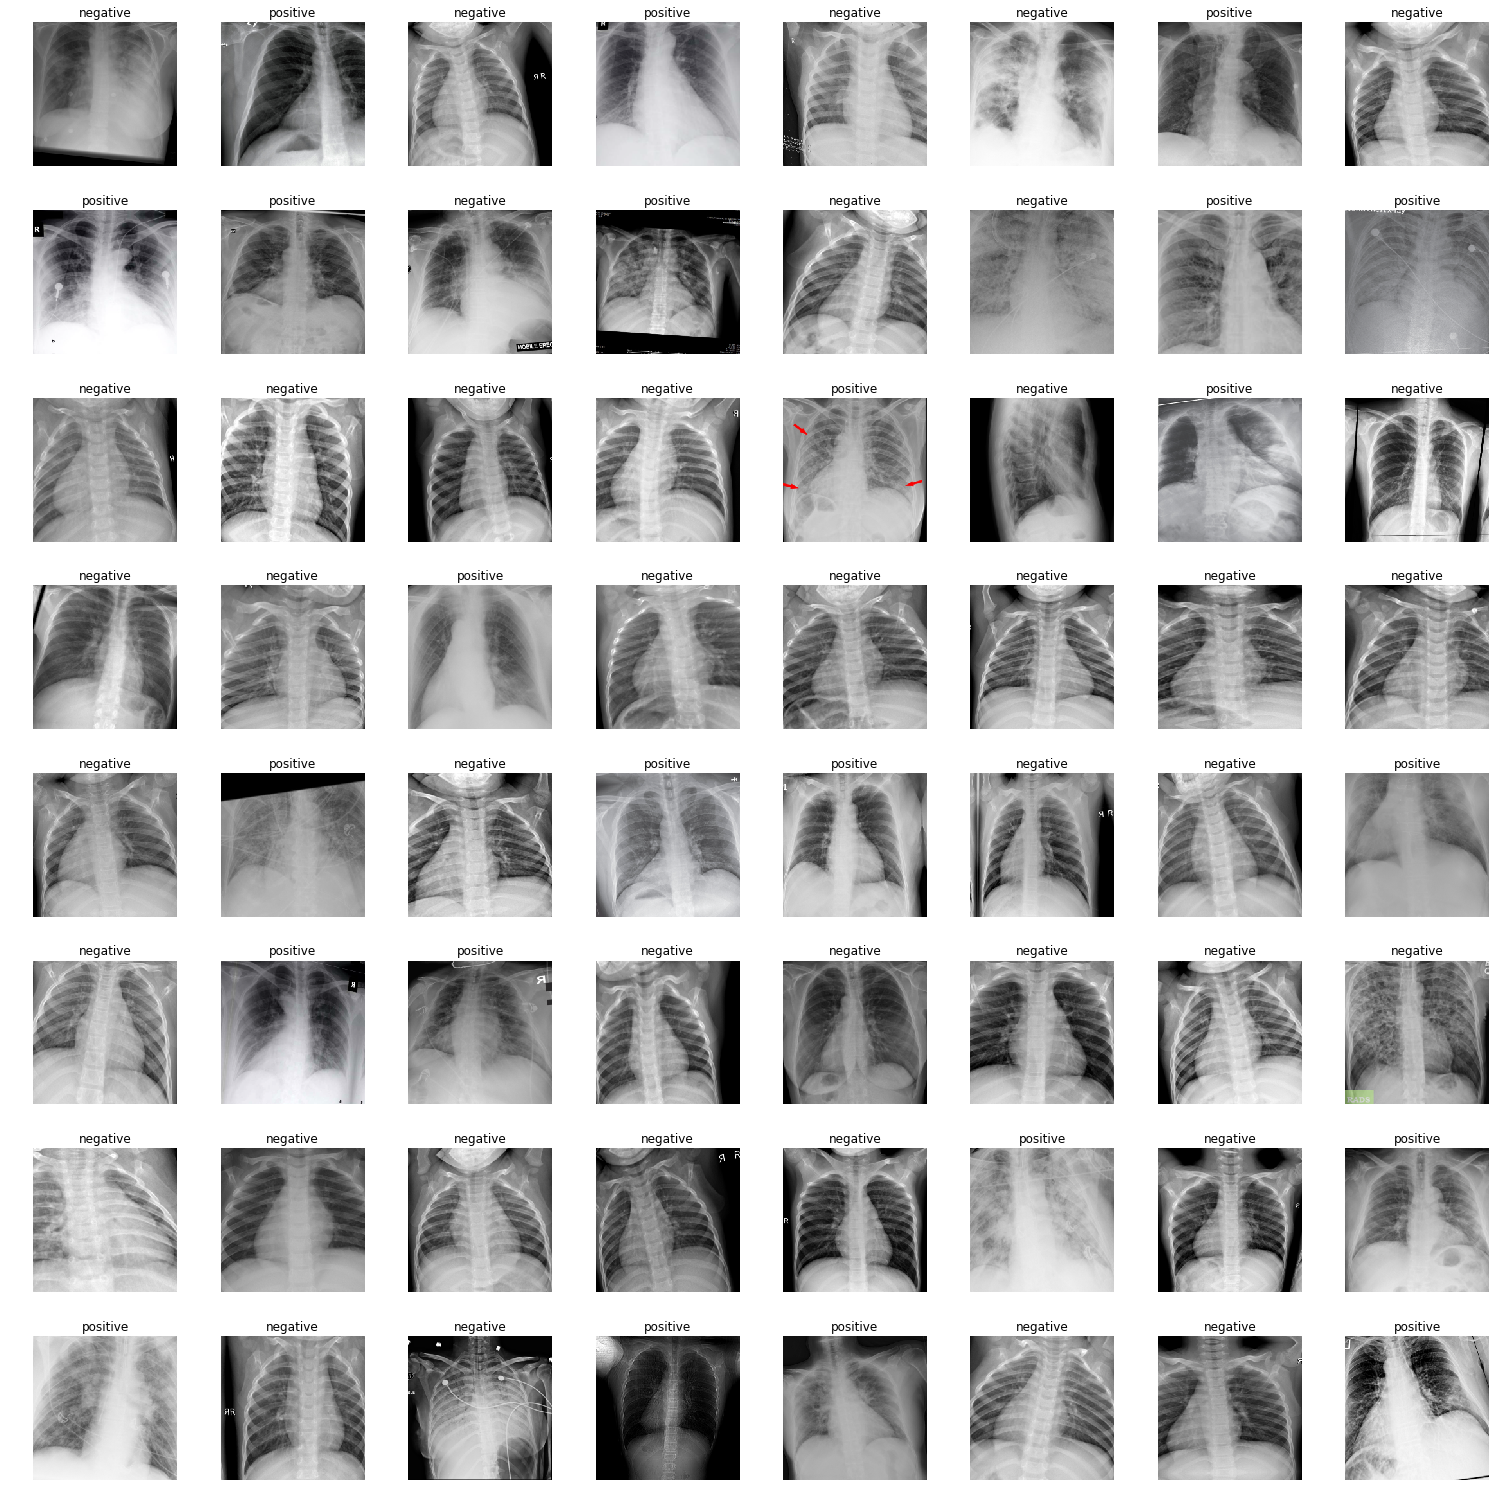

In [13]:
data.show_batch(rows=80, figsize=(21,21))

To my untrained eyes, it looks like the images look consistent. We are going to use a resnet50 and leverage Kaggle free GPU Quota. Let's start training ten cycles.

In [14]:
learn = cnn_learner(data, models.resnet50, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/checkpoints/resnet50-19c8e357.pth


Let's first fit 10 cycles and see how it improves

In [15]:
learn.fit_one_cycle(5)

epoch,train_loss,valid_loss,error_rate,time
0,1.067158,0.761341,0.258621,00:22
1,0.969550,0.547705,0.172414,00:18
2,0.878713,0.493636,0.155172,00:19
3,0.770879,0.516133,0.155172,00:18
4,0.676176,0.588684,0.155172,00:19


Looks like we can do better, let's run ten cycles more.

In [16]:
learn.fit_one_cycle(5)

epoch,train_loss,valid_loss,error_rate,time
0,0.377819,0.750371,0.155172,00:19
1,0.357246,0.931277,0.172414,00:19
2,0.354035,1.027927,0.206897,00:19
3,0.339319,1.071670,0.224138,00:18
4,0.333478,0.938677,0.206897,00:20


It looks good. We are going to keep the 5.5% error for now and try the next data frame


In [17]:
learn.save('stage-1')

## Second case: COVID-19 patients and pneumonia patients

df2 = covid_df.append(pneumonia_df, ignore_index = True)
df2 = df2.sample(frac=1).reset_index(drop=True)
np.random.seed(42)
data2 = ImageDataBunch.from_df(
        '/', 
        df2, 
        fn_col='filename',
        label_col='finding',
        ds_tfms=get_transforms(), ## data augmentation: flip horizozntally
        size=224, 
        num_workers=4
    ).normalize(imagenet_stats)

learn2 = cnn_learner(data2, models.resnet50, metrics=error_rate)
learn2.fit_one_cycle(5)

Let's run some more cycles

learn2.fit_one_cycle(10)

learn2.fit_one_cycle(10)

That's a nice error rate. Let's save ```learn2``` and starti optimizing

learn2.save('learn2-stage-1')


# 3. Optmize

Results for the first case were already pretty solid in **Part 2**. We are going to first optimize the results for the first case and then optimize results for the second case. Then, if the two cases accuracy do not differ too much, we will be confident in our result and try to predict random images online.

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


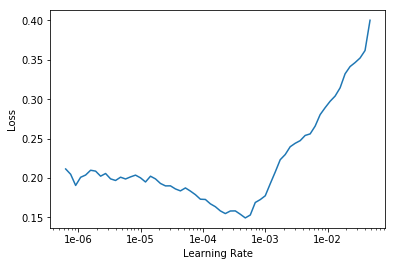

In [18]:
learn.load('stage-1')
learn.unfreeze()
learn.lr_find()
learn.recorder.plot()

 The longest downward shape is found in the region around ```1e-4``` let's use that as our starting point

In [19]:
learn.fit_one_cycle(10, max_lr=slice(7e-5,2e-4))

epoch,train_loss,valid_loss,error_rate,time
0,0.180453,0.734373,0.155172,00:17
1,0.180965,0.602691,0.172414,00:17
2,0.183398,0.504723,0.155172,00:17
3,0.167105,0.666022,0.155172,00:18
4,0.157537,1.021038,0.224138,00:17
5,0.148230,1.535116,0.344828,00:18
6,0.135003,1.143087,0.206897,00:19
7,0.126004,0.844857,0.155172,00:17
8,0.113791,0.791719,0.155172,00:16
9,0.110338,0.730231,0.155172,00:18


I obtained the 0% error rate after a updated my notebook on kaggle and used a balanced dataset. This error rate though, is probably due to the fact that I am still collecting data and would require much more images to have an more stable error rate.

In [20]:
learn.save('stage-2')

In [21]:
learn.fit_one_cycle(2, max_lr=slice(7e-5,2e-4))

epoch,train_loss,valid_loss,error_rate,time
0,0.087168,0.738216,0.155172,00:18
1,0.063733,0.727640,0.120690,00:17


Looks like the error rate is not really moving. With 3.6% error rate we might be satisfied with this first results. We are going to save and plot the confusion matrix.

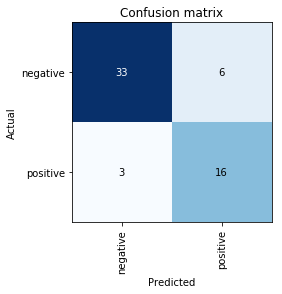

In [22]:
learn.load('stage-2')
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Since the error rate is 0, the confusion matrix shows we have no errors.

## Second case: COVID-19 patients and pneumonia patients

learn2.load('learn2-stage-1')

learn2.unfreeze()

learn2.lr_find()

learn2.recorder.plot()


 The longest downward shape is found in the region around ???????????```1e-4``` let's use that as our starting point

learn2.load('learn2-stage-1')
learn2.unfreeze()
learn2.fit_one_cycle(4, max_lr=slice(7e-5,1e-4))

learn2.save('learn2-stage-2')

Both cases have an error rate < 3%. Given the scarsity of data, this is a promising first result. Since using both models, covid-19 prediction seems to be consistent, we can be confident enough in its predictions.

# Test

In [23]:
# learn = cnn_learner(data, models.resnet50, metrics=error_rate)
# learn.load('stage-3')
# interp = ClassificationInterpretation.from_learner(learn)
img = open_image(input_path/'testimg/df1053d3e8896b53ef140773e10e26_gallery.jpeg')
learn.predict(img)

(Category positive, tensor(1), tensor([2.9113e-05, 9.9997e-01]))

That image is taken from https://radiopaedia.org/images/52197348 and it is an image of a positive patient.

# What's next?

First of all, I would like to incorporate scans from other sources and see if accuracy and generalization might increase.
Today, while I was about to pusblish this article, I found out that [MIT](https://www.technologyreview.com/s/615399/coronavirus-neural-network-can-help-spot-covid-19-in-chest-x-ray-pneumonia/) has released a database containing xrays images of covid patients. Next, I am going to incorporate MIT's database and see where we get.